In [13]:
#pip install pandas numpy matplotlib plotly seaborn country_converter

In [14]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

import plotly.express as px
import seaborn as sns

import country_converter as coco

In [15]:
try:
    df_movies = pd.read_csv("../data/clean_datasets/df_movies.csv")
    df_actors = pd.read_csv("../data/clean_datasets/df_actors.csv")
    df_countries = pd.read_csv("../data/clean_datasets/df_countries.csv")
    df_crew = pd.read_csv("../data/clean_datasets/df_crew.csv")
    df_genres = pd.read_csv("../data/clean_datasets/df_genres.csv")
    df_languages = pd.read_csv("../data/clean_datasets/df_languages.csv")
    df_posters = pd.read_csv("../data/clean_datasets/df_posters.csv")
    df_releases = pd.read_csv("../data/clean_datasets/df_releases.csv")
    df_studios = pd.read_csv("../data/clean_datasets/df_studios.csv")
    df_themes = pd.read_csv("../data/clean_datasets/df_themes.csv")

    df_tomatoes = pd.read_csv("../data/clean_datasets/df_tomatoes.csv")
    df_oscars = pd.read_csv("../data/clean_datasets/df_oscars.csv")
except Exception as e:
    print(e)

# Analisi dei Dati
Andiamo ad analizzare i nostri dati cinematografici in due storie principali:
- Il Grande Quadro, dove ci faremo un'idea su come le opinioni del cinema cambino.
- La Formula del Successo, andremo a vedere i dettagli che rendono un film un cult.

## Il Grande Quadro

### Analisi 1: La Teoria del "Blockbuster Bloat" (Tempo vs Qualità)
- Nel corso del tempo i film sono diventati sempre più moderni e avanzati, ma ciò significa che sono diventati anche più lunghi e migliori?
- O stiamo assistendo solo a un aumento (bloat) della durata senza un reale guadagno nella qualità?

In [16]:
df_trend = df_movies.copy()

df_trend = df_trend[ (df_trend['date'] >= 1920) & (df_trend['date'] <= 2024) ]
df_trend['date'] = df_trend['date'].astype(int)

yearly_stats = df_trend.groupby('date')[['minute', 'rating']].mean()

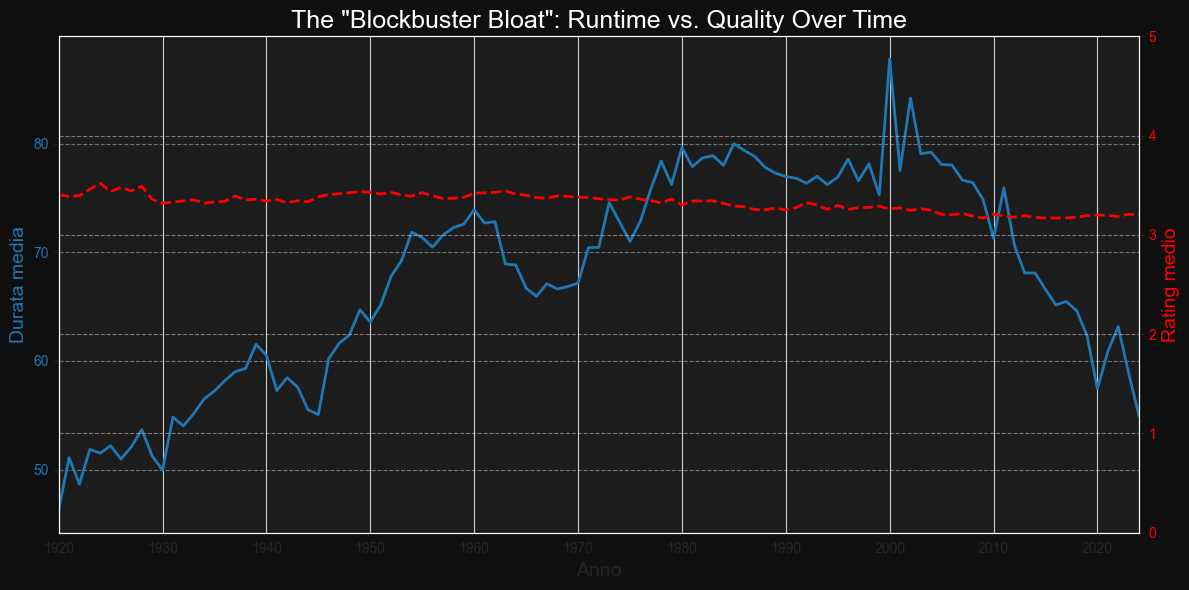

In [17]:
fig, ax1 = plt.subplots(figsize=(12, 6))

plt.plot()

ax1.plot(
    yearly_stats.index,
    yearly_stats['minute'],
    color='#1f77b4',
    linewidth=2,
    label='Durata'
)

fig.patch.set_facecolor('#0F0F0F')
ax1.set_facecolor('#1C1C1C')

ax1.xaxis.grid(True, color='white', linestyle='-', alpha=0.8)
ax1.yaxis.grid(True, color='lightblue', linestyle='--', alpha=0.5)

ax1.set_xlabel('Anno', fontsize=14)
ax1.set_ylabel('Durata media', color='#1f77b4', fontsize=14)
ax1.set_xlim(1920, 2024)
ax1.set_xticks(np.arange(1920, 2024, 10))

ax1.tick_params(axis='y', labelcolor='#1f77b4')


ax2 = ax1.twinx()

ax2.set_ylabel('Rating medio', color='red', fontsize=14)
ax2.plot(
    yearly_stats.index,
    yearly_stats['rating'],
    color='red',
    linewidth=2,
    linestyle='--',
    label='Rating'
)

ax2.tick_params(axis='y', labelcolor='red')
ax2.yaxis.grid(True, color='#ffcccc', linestyle='--', alpha=0.5)

ax2.set_ylim(0, 5)

plt.title('The "Blockbuster Bloat": Runtime vs. Quality Over Time', fontsize=18, color='white')
fig.tight_layout()

plt.show()

In questo grafico esaminiamo la relazione tra la **durata media** dei film e il loro **rating medio**:
- **linea blu:** notiamo un picco significativo della durata media dei film intorno al 2000 passando dai 55 minuti circa agli 88 minuti e un calo drastico dopo il 2010 ritornando ai 60 minuti.
- **linea rossa:** contrariamente alla linea blu possiamo notare che il rating medio dei film è rimasto invariato nel corso del tempo (tra 3.0 e 3.5).
- **conclusione:** La nostra analisi conferma la nostra teoria. Sebbene i film siano diventati molto più lunghi nel corso del tempo questo non ha portato ad un aumento della qualità in quanto il rating è rimasto invariato. Al contrario notiamo una regressione della durata dovuta probabilmente alla nascita dei contenuti in streaming.

 ### Analisi 2: Mappatura dell'eccellenza (Geografia del Cinema)
- Abbiamo visto che durata non è sinonimo di qualità, allora la geografia lo è?
- Sappiamo che Hollywood è il centro di produzione della gran parte dei film, ma produce anche i migliori?

In [18]:
df_map_data = pd.merge(
    df_countries[['id_film', 'country']],
    df_movies[['id_film', 'rating']],
    on='id_film'
)

country_means = df_map_data.groupby('country')['rating'].agg(['mean', 'count']).reset_index()

country_means.columns = ['country', 'rating', 'Movie_Count']

# Mappa di Paesi che non esistono più
country_patch = {
    'East Germany': 'Germany',
    'USSR': 'Russia',
    'Yugoslavia': 'Serbia',
    'Serbia and Montenegro': 'Serbia',
    'Netherlands Antilles': 'Netherlands'
}

country_means['country'] = country_means['country'].replace(country_patch)

# Usiamo una libreria per convertire i nomi dei Paesi in ISO3
cc = coco.CountryConverter()
country_means['iso'] = cc.convert(names=country_means['country'], to='ISO3')

fig = px.choropleth(
    country_means,
    locations="iso",
    locationmode="ISO-3",
    color="rating",
    hover_name="country",
    color_continuous_scale="Viridis",
    title="Rating Medio per Paese"
)
fig.show()

Attraverso quest'analisi spostiamo l'attenzione dall'arco **temporale** a quello **spaziale**. La mappa indica con i colori più chiari (giallo/verde chiaro) un raring medio più alto e quelli più scuri (blu/viola) un rating più basso.
- Gli USA pur dominando il mercato per "quantità" hanno un rating che si aggira tra i 3.0 e i 3.2
- L'Est al contrario mostra tonalità più chiare, dovuto probabilmente da una selezione più accurata
- Quella che prevale a vista d'occhio è una nazione in Nord Africa, la Libia, probabilmente dovuto ad un numero di produzioni ridotto ma molto amati
- Quest'analisi suggerisce che "qualità" e "popolarità" non vanno spesso di pari passo ma che ogni film deve lottare di più per emergere

### Analisi 3 "The Popcorn Gap" (Critica vs. Pubblico)


- Come è cambiato il rating della critica e del pubblico nel corso del tempo?
- Chi decide se questi film sono belli?
- I critici sono diventati più cattivi nel corso del tempo? Oppure è il pubblico ad essere diventato più difficile da accontentare?
- Pubblico e Critica: hanno le stesse opinioni sugli stessi film?


In [19]:
df_tomatoes_merge = df_tomatoes.copy()
df_movies_merge = df_movies.copy()

df_tomatoes_merge['match_title'] = df_tomatoes_merge['movie_title'].str.lower().str.strip()
df_movies_merge['match_title'] = df_movies_merge['name'].str.lower().str.strip()

clean_reviews = df_tomatoes_merge[df_tomatoes['score'] != -1].copy()

clean_movies = df_movies_merge[df_movies['date'].notna()].copy()


reviews_with_date = pd.merge(
    clean_reviews[['match_title', 'score', 'top_critic', 'review_date']],
    df_movies_merge[['match_title', 'date']],
    on='match_title',
    how='inner'
)

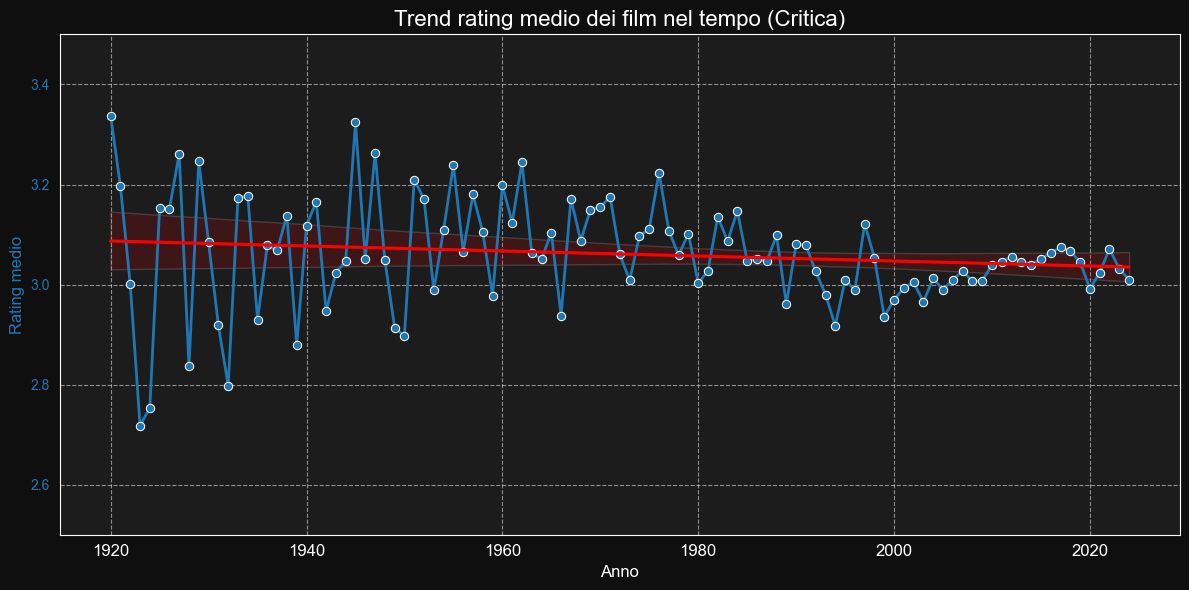

In [20]:
top_trend = reviews_with_date[reviews_with_date['top_critic'] == True].groupby('date')['score'].mean().reset_index()
top_trend = top_trend[(top_trend['date'] >= 1920) & (top_trend['date'] <= 2024)]

fig = plt.figure(figsize=(12,6))
sns.lineplot(
    data=top_trend,
    x='date',
    y='score',
    marker='o',
    linewidth=2,
    color='#1f77b4'
)

sns.regplot(
    x=top_trend['date'],
    y=top_trend['score'],
    scatter=False,
    color="red",
    label="Trend"
)

plt.title("Trend rating medio dei film nel tempo (Critica)", fontsize=16, color='white')
plt.xlabel("Anno", fontsize=12, color='white')
plt.ylabel("Rating medio", fontsize=12, color='#1f77b4')
plt.yticks(color='#1f77b4')
plt.xticks(fontsize=12, color='white')
plt.ylim(2.5, 3.5)
plt.grid(True, linestyle='--', alpha=0.5)

fig.patch.set_facecolor('#0F0F0F')
plt.gca().set_facecolor('#1C1C1C')

plt.tight_layout()
plt.show()

 I film tra gli anni 1920-1960 hanno picchi molto accentuati. Queste oscillazioni evidenti sono causati da pochi capolavori o fallimenti in grado di influenzare la media

La linea rossa indica la valutazione della critica nel corso del tempo la quale è quasi sempre costante o in lieve discesa, suggerendo una media sempre attorno ai 3.0-3.1

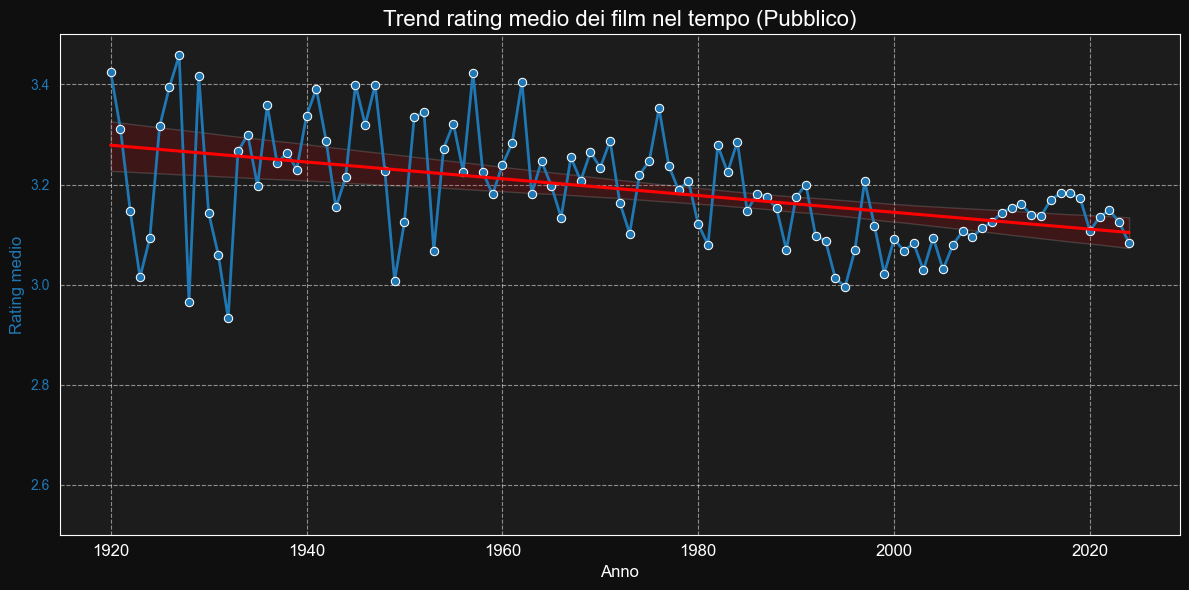

In [21]:
public_trend = reviews_with_date[reviews_with_date['top_critic'] == False].groupby('date')['score'].mean().reset_index()
public_trend = public_trend[(public_trend['date'] >= 1920) & (public_trend['date'] <= 2024)]

fig = plt.figure(figsize=(12,6))
sns.lineplot(
    data=public_trend,
    x='date',
    y='score',
    marker='o',
    linewidth=2,
    color='#1f77b4'
)

sns.regplot(
    x=public_trend['date'],
    y=public_trend['score'],
    scatter=False,
    color="red",
    label="Trend"
)
plt.title("Trend rating medio dei film nel tempo (Pubblico)", fontsize=16, color='white')
plt.xlabel("Anno", fontsize=12, color='white')
plt.ylabel("Rating medio", fontsize=12, color='#1f77b4')
plt.yticks(color='#1f77b4')
plt.xticks(fontsize=12, color='white')
plt.ylim(2.5, 3.5)
plt.grid(True, linestyle='--', alpha=0.5)

fig.patch.set_facecolor('#0F0F0F')
plt.gca().set_facecolor('#1C1C1C')

plt.tight_layout()
plt.show()

A differenza della critica, il pubblico recensisce i film del passato in modo più "generoso", ciò lo possiamo vedere attorno ai rating per gli anni '20 nella quale vi era una media generale del 3.3. Per i film moderni invece il pubblico è diventato più esigente allineandosi drasticamente ai valori della critica: 3.1 .

Se per il cinema "di un tempo" il pubblico mostrava più entusiasmo messo in confronto con la critica, nel cinema "d'oggi" non è più così in quanto le medie sono quasi uguali. Questo è dovuto probabilmente ad un aumento delle aspettative e delle esigenze del pubblico.

-Possiamo notare in entrambi i grafici che c'è molto rumore prima del 2000, come mai?

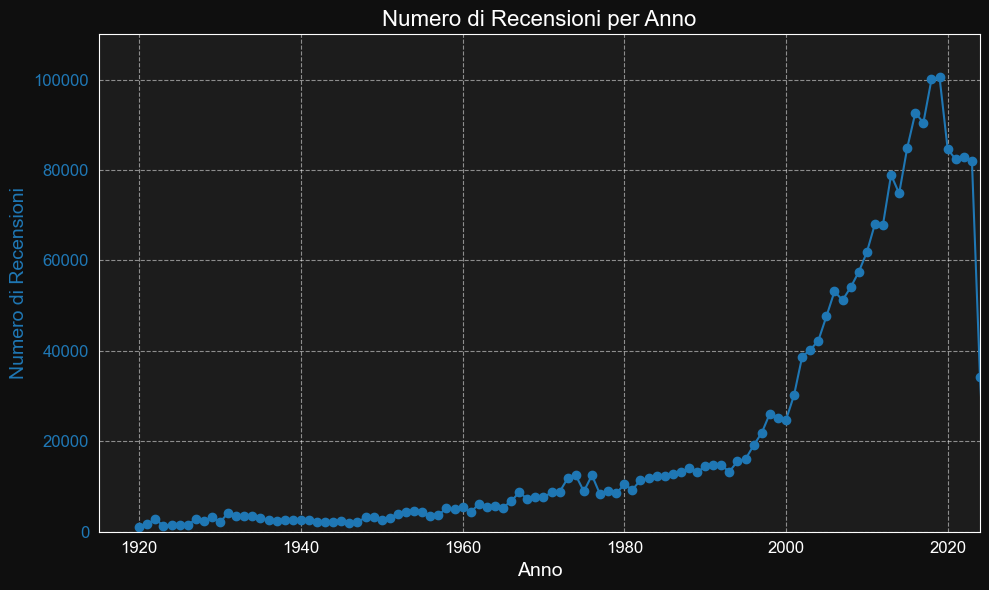

In [22]:
reviews_per_year = reviews_with_date.groupby('date').size()

reviews_per_year = reviews_per_year[reviews_per_year.index >= 1920]

fig = plt.figure(figsize=(10, 6))

plt.plot(
    reviews_per_year.index,
    reviews_per_year.values,
    marker='o',
    linestyle='-',
    color='#1f77b4',
    label="Numero di Recensioni")

plt.title("Numero di Recensioni per Anno", fontsize=16, color='white')
plt.xlabel("Anno", fontsize=14, color='white')
plt.ylabel("Numero di Recensioni", fontsize=14, color='#1f77b4')
plt.yticks(color='#1f77b4')
plt.xticks(fontsize=12, color='white')

plt.xlim(1915, 2024)
plt.ylim(0, 110000)
plt.yticks(fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)
fig.patch.set_facecolor('#0F0F0F')
plt.gca().set_facecolor('#1C1C1C')
plt.tight_layout()
plt.show()

- 1920-1965: possiamo notare come la linea rimanga quasi piatta, perchè l'interesse del pubblico moderno nel recensire film più datati non c'è, in quanto interessati a film più recenti.
- 1965-1990: da qui in poi la nostra curva inizia a salire. In questi anni si producono molti film cult che influenzeranno i gusti e la criosità del pubblico, della critica e la storia del cinema fino ad oggi.
- 1995-2019: è il periodo di crescita massima, i film dell'era contemporanea prevalgono per il numero di recensioni e interesse generale.
- 2020-2024: Il grafico mostra un crollo verticale. Questo è l'impatto visivo dovuto probabilmente dal COVID-19 che ha portato ad uno svutamento delle sale e un consegunte disinteresse nelle produzioni di questi anni.


In [23]:
df_tomatoes_merge['is_fresh'] = df_tomatoes_merge['review_type'].apply(lambda x: 1 if x == 'Fresh' else 0)

top_critics = df_tomatoes_merge[df_tomatoes_merge['top_critic'] == True]

critic_consensus = top_critics.groupby('match_title')['is_fresh'].mean().reset_index()
critic_consensus.columns = ['match_title', 'critic_pct']

audience_consensus = df_tomatoes_merge.groupby('match_title')['is_fresh'].mean().reset_index()
audience_consensus.columns = ['match_title', 'audience_pct']

df_gap_real = pd.merge(audience_consensus, critic_consensus, on='match_title', how='inner')

df_gap_real['audience_score_norm'] = df_gap_real['audience_pct'] * 100

df_gap_real['critic_score_norm'] = df_gap_real['critic_pct'] * 100

df_gap_real['gap'] = df_gap_real['audience_score_norm'] - df_gap_real['critic_score_norm']
df_sample = df_gap_real.sample(n=1000, random_state=42)

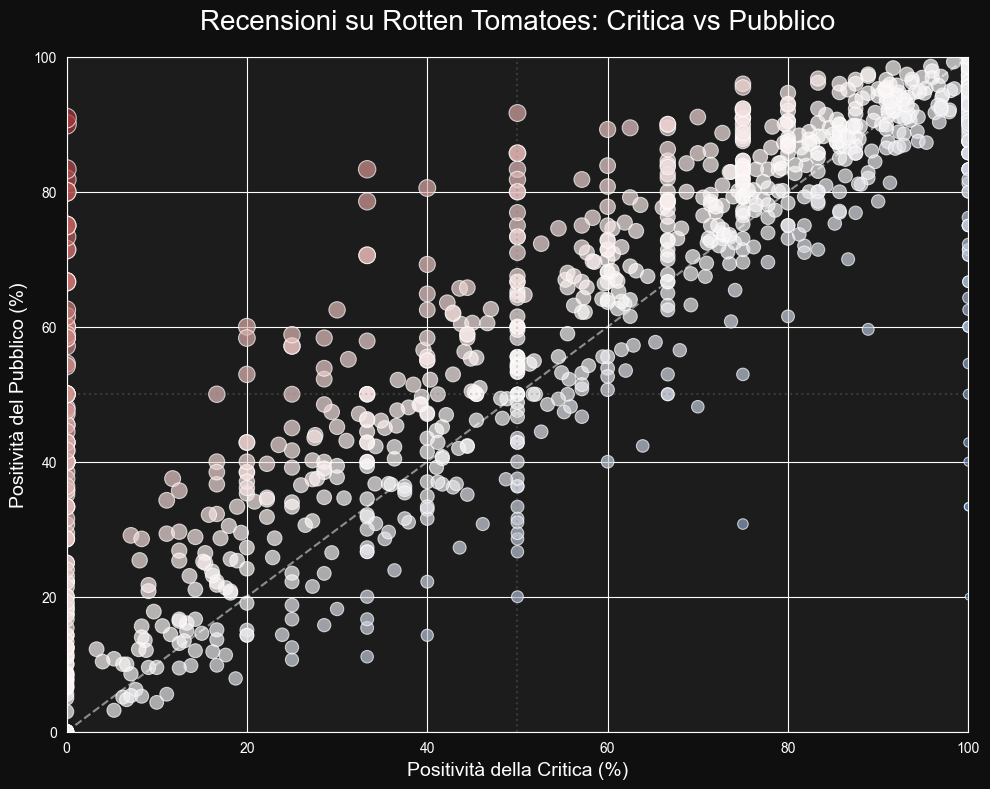

In [24]:
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('#0F0F0F')
ax.set_facecolor('#1C1C1C')

sns.scatterplot(
    data=df_sample,
    x='critic_score_norm',
    y='audience_score_norm',
    hue='gap',
    palette='vlag',
    size='gap',
    sizes=(20, 200),
    alpha=0.7,
    ax=ax,
    legend=False
)
ax.plot([0, 100], [0, 100], color='white', linestyle='--', alpha=0.5) # Perfect Agreement
ax.axhline(50, color='gray', linestyle=':', alpha=0.3)
ax.axvline(50, color='gray', linestyle=':', alpha=0.3)

ax.set_title('Recensioni su Rotten Tomatoes: Critica vs Pubblico', fontsize=20, color='white', pad=20)
ax.set_xlabel('Positività della Critica (%)', fontsize=14, color='white')
ax.set_ylabel('Positività del Pubblico (%)', fontsize=14, color='white')
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

Il grafico confronta la percentuale di gradimento della Critica (asse X) con quella del Pubblico (asse Y).
I punti dimostrano che il pubblico è più benevolo nel recensire perchè la maggior parte dei film si trova sopra la linea diagonale tratteggiata, indicando che in media esso rilascia feedback più positivi rispetto alla critica.

## La Formula del Successo

### Analisi 4: "Star Power": L'influenza tra attore e successo.
- Assumere un attore famoso è marketing o una dimostrazione di qualità?
- Fare tanti film significa essere bravi oppure essere disposti a tutto?
- Il successo di un film è influenzato dalla bravura di un attore?

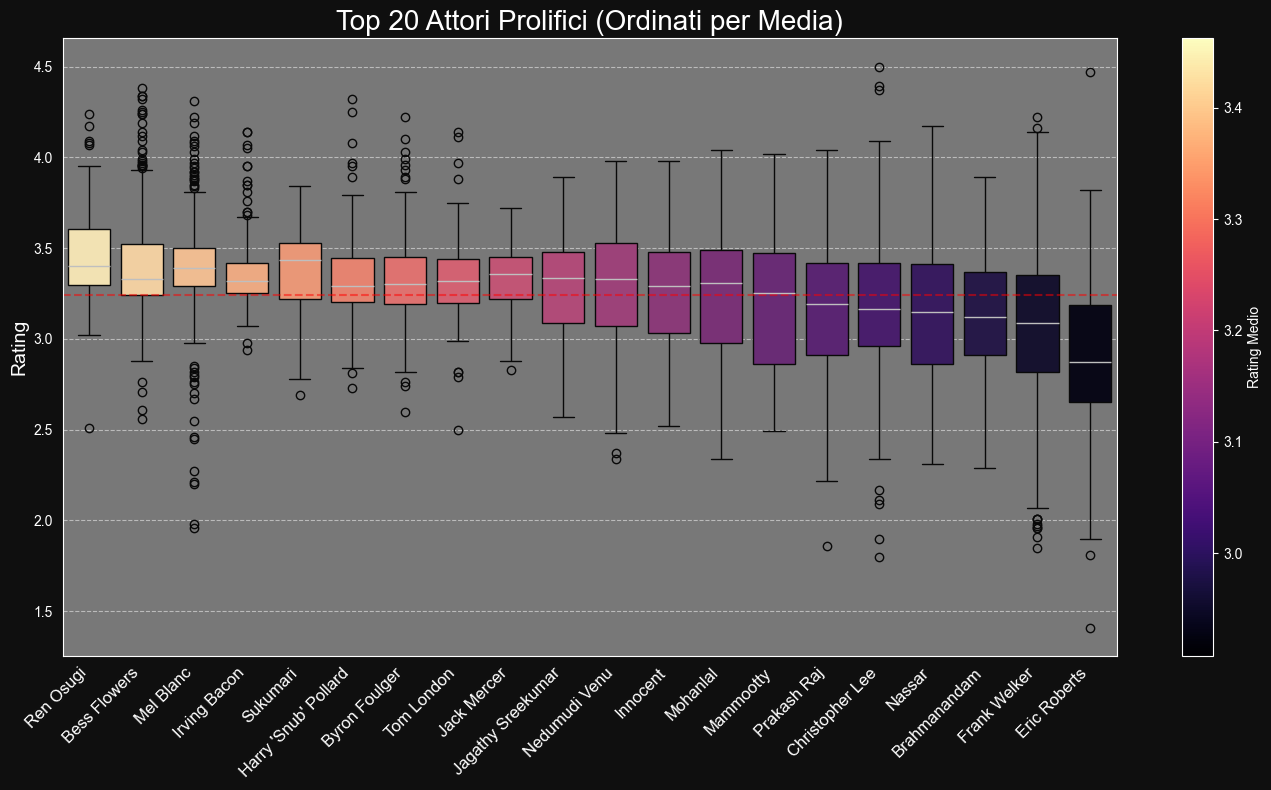

In [25]:
df_actor_ratings = pd.merge(
    df_movies[['id_film', 'rating']],
    df_actors[['id_film', 'name']],
    on='id_film',
    how='inner'
)
top_stars = df_actor_ratings['name'].value_counts().nlargest(20).index
df_stars = df_actor_ratings[df_actor_ratings['name'].isin(top_stars)]

# Ordiniamo in modo crescente, 'magma' va ds scuro a chiaro
actor_order_asc = df_stars.groupby('name')['rating'].mean().sort_values(ascending=True).index
actor_order_desc = actor_order_asc[::-1] #invertiamo (migliore a sinistra)

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(14, 8), facecolor='#0F0F0F')
ax.set_facecolor('#787878')

sns.boxplot(
    data=df_stars,
    x='name',
    y='rating',
    order=actor_order_desc,
    hue_order=actor_order_desc,
    palette='magma_r',
    hue='name',
    legend=False,
    ax=ax,
    medianprops=dict(color='#BFBFBF')
)

# Linea per riferimento
ax.axhline(df_movies['rating'].mean(), color='red', linestyle='--', alpha=0.5, label='Global Avg')

# Normalizzazione della media
norm = plt.Normalize(
    df_stars.groupby('name')['rating'].mean().min(),
    df_stars.groupby('name')['rating'].mean().max()
)
sm = cm.ScalarMappable(cmap='magma', norm=norm)
cbar = plt.colorbar(sm, ax=ax)

cbar.set_label('Rating Medio', color='white')
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')

plt.title('Top 20 Attori Prolifici (Ordinati per Media)', fontsize=20, color='white')
plt.xlabel('')
plt.ylabel('Rating', fontsize=14, color='white')
plt.xticks(rotation=45, ha='right', fontsize=12, color='white')
plt.yticks(color='white')
ax.yaxis.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Esaminando i dati abbiamo deciso di ristringere il campo ai 20 attori più presenti nel nostro dataset e utilizzando un Box Plot ordinato per media abbiamo visualizzato la distribuzione dei voti per ogni attore.
- A sinistra ci sono tutti gli attori con una media alta e con la "box" situata sopra la linea rossa tratteggiata. Questo indica che è statisticamente improbabile ottenere film mediocri con essi.
- A destra i box oltre a tendere verso il viola/nero scendono al di sotto della linea tratteggiata. La loro fama dipende dalla quantità e non qualità del film.

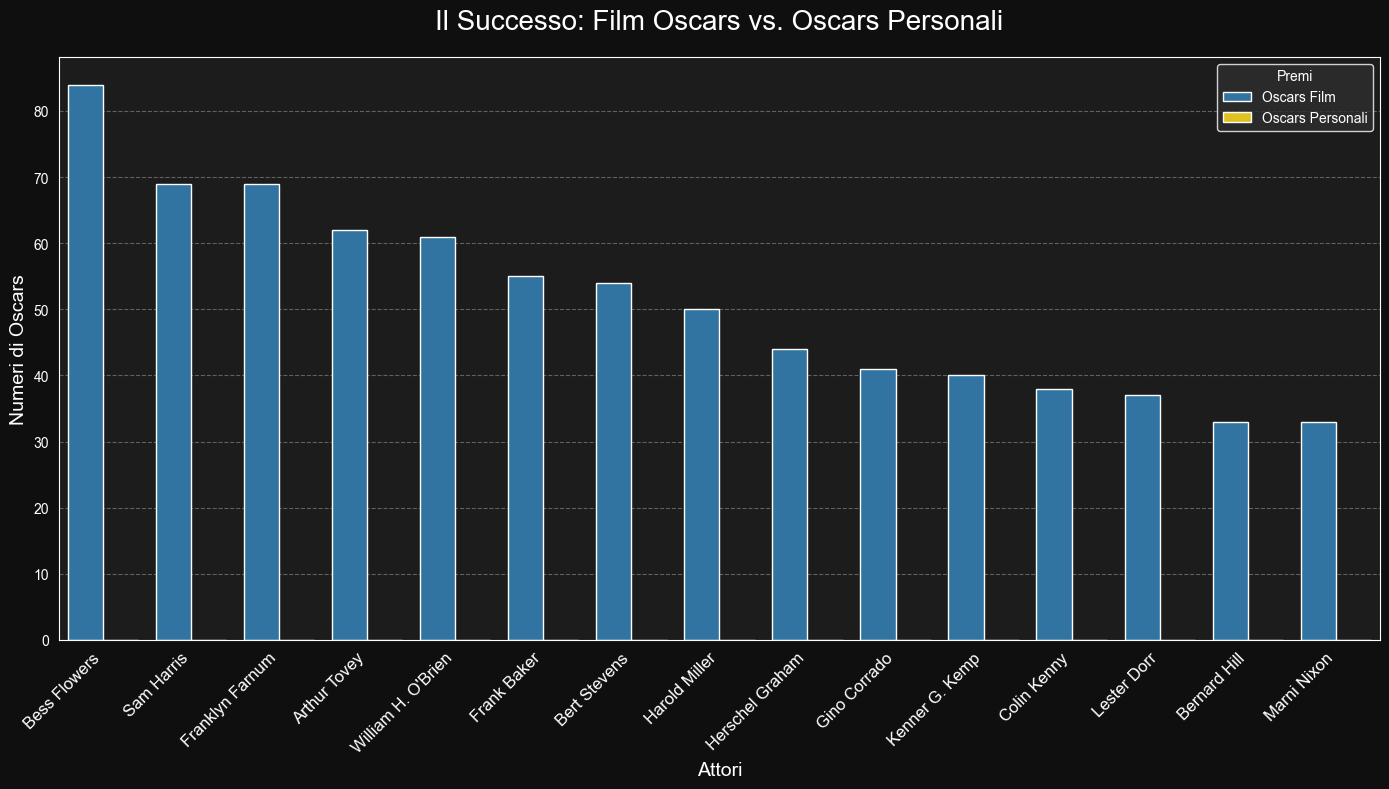

In [26]:
df_oscars_merge = df_oscars.copy()
df_oscars_merge['match_title'] = df_oscars_merge['film'].astype(str).str.lower().str.strip()
df_movies['match_title'] = df_movies['name'].astype(str).str.lower().str.strip()

oscars_won = df_oscars_merge[df_oscars_merge['winner'] == True].copy()

merged_data = pd.merge(
    oscars_won,
    df_movies[['match_title', 'id_film', 'date']],
    left_on=['match_title', 'year_film'],
    right_on=['match_title', 'date'],
    how='inner'
)

merged_data = pd.merge(merged_data, df_actors[['id_film', 'name']], on='id_film', how='inner')



film_oscar_counts = merged_data.groupby('name_y').size().reset_index(name='Oscars Film ')

personal_wins = merged_data[
    merged_data['category'].str.contains('ACTOR|ACTRESS', case=False, na=False) &
    (merged_data['name_x'] == merged_data['name_y'])
]
personal_oscar_counts = personal_wins.groupby('name_y').size().reset_index(name='Oscars Personali')


df_comparison = pd.merge(film_oscar_counts, personal_oscar_counts, on='name_y', how='left').fillna(0)

df_comparison.rename(columns={'name_y': 'name'}, inplace=True)

top_oscar_magnets = df_comparison.sort_values(by='Oscars Film ', ascending=False).head(15)
df_melted = top_oscar_magnets.melt(id_vars='name', var_name='Type', value_name='Count')

plt.style.use('dark_background')
plt.figure(figsize=(14, 8), facecolor='#0F0F0F')
ax = plt.gca()
ax.set_facecolor('#1C1C1C')

sns.barplot(
    data=df_melted,
    x='name',
    y='Count',
    hue='Type',
    palette={'Oscars Film ': '#1f77b4', 'Oscars Personali': '#ffd700'},
    ax=ax
)

plt.title('Il Successo: Film Oscars vs. Oscars Personali', fontsize=20, color='white', pad=20)
plt.xlabel('Attori', fontsize=14, color='white')
plt.ylabel('Numeri di Oscars', fontsize=14, color='white')
plt.xticks(rotation=45, ha='right', fontsize=12, color='white')
plt.yticks(color='white')
plt.legend(title='Premi', facecolor='#2E2E2E', edgecolor='white', labelcolor='white')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

Questo grafico mostra gli attori ordinati in base al numero di Oscars vinti dai film in cui sono apparsi.
Come si può notare, i primi posti non sono occupati da attori famosi ma da delle comparse; questo tipo di visualizzazione, dunque, non è utile per valutare se le stelle del cinema influenzino o meno il successo dei film a cui partecipano.

Proviamo a fare il contrario, partiamo dagli attori che hanno vinto più Oscars personali e vediamo quanti oscar hanno vinto i loro film in totale.

In [27]:
df_oscars_merge = df_oscars.copy()
df_oscars_merge['match_title'] = df_oscars_merge['film'].astype(str).str.lower().str.strip()
df_movies['match_title'] = df_movies['name'].astype(str).str.lower().str.strip()

oscars_won = df_oscars_merge[df_oscars_merge['winner'] == True].copy()

merged_data = pd.merge(
    oscars_won,
    df_movies[['match_title', 'id_film', 'date']],
    left_on=['match_title', 'year_film'],
    right_on=['match_title', 'date'],
    how='inner'
)
merged_data = pd.merge(merged_data, df_actors[['id_film', 'name']], on='id_film', how='inner')
# Questo creerà due versioni di name: 'name_x' e 'name_y' rispettivamente df_movies['name'] e df_actors['name']

# A noi interessa il 'name' dell attore
film_oscar_counts = merged_data.groupby('name_y').size().reset_index(name='Oscars Film ')

personal_wins = merged_data[
    merged_data['category'].str.contains('ACTOR|ACTRESS', case=False, na=False) &
    (merged_data['name_x'] == merged_data['name_y'])
]

personal_oscar_counts = personal_wins.groupby('name_y').size().reset_index(name='Oscars Personali')

df_comparison = pd.merge(film_oscar_counts, personal_oscar_counts, on='name_y', how='left').fillna(0)

df_comparison.rename(columns={'name_y': 'name'}, inplace=True)

top_legends = df_comparison.sort_values(by=['Oscars Personali', 'Oscars Film '], ascending=False).head(15)

df_melted = top_legends.melt(id_vars='name', var_name='Type', value_name='Count')

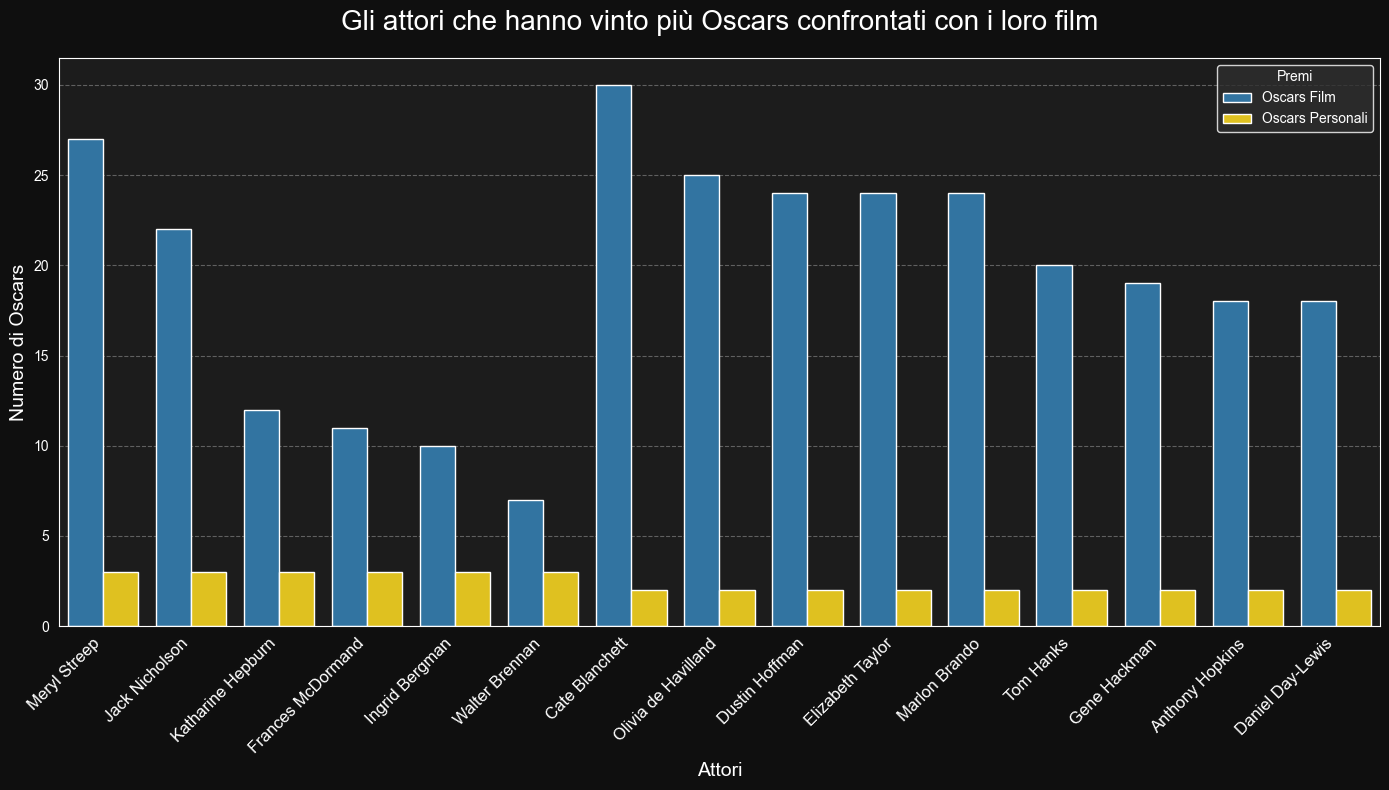

In [28]:
plt.style.use('dark_background')
plt.figure(figsize=(14, 8), facecolor='#0F0F0F')
ax = plt.gca()
ax.set_facecolor('#1C1C1C')

sns.barplot(
    data=df_melted,
    x='name',
    y='Count',
    hue='Type',
    palette={'Oscars Film ': '#1f77b4', 'Oscars Personali': '#ffd700'}, # Blue vs Gold
    ax=ax
)

plt.title('Gli attori che hanno vinto più Oscars confrontati con i loro film', fontsize=20, color='white', pad=20)
plt.xlabel('Attori', fontsize=14, color='white')
plt.ylabel('Numero di Oscars', fontsize=14, color='white')
plt.xticks(rotation=45, ha='right', fontsize=12, color='white')
plt.yticks(color='white')
plt.legend(title='Premi', facecolor='#2E2E2E', edgecolor='white', labelcolor='white')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

Il grafico rappresentato dalle colonne gialle mostra come sia difficile vincere più di 3 Oscars individuali in quanto per quasi tutti gli attori sono livellate alla stessa altezza.
Le colonne blu invece mostrano la capacità di un attore nell'essere selezionato nelle produzioni migliori, le quali hanno vinto Oscars indipendentemente dalla bravura dell'attore stesso.

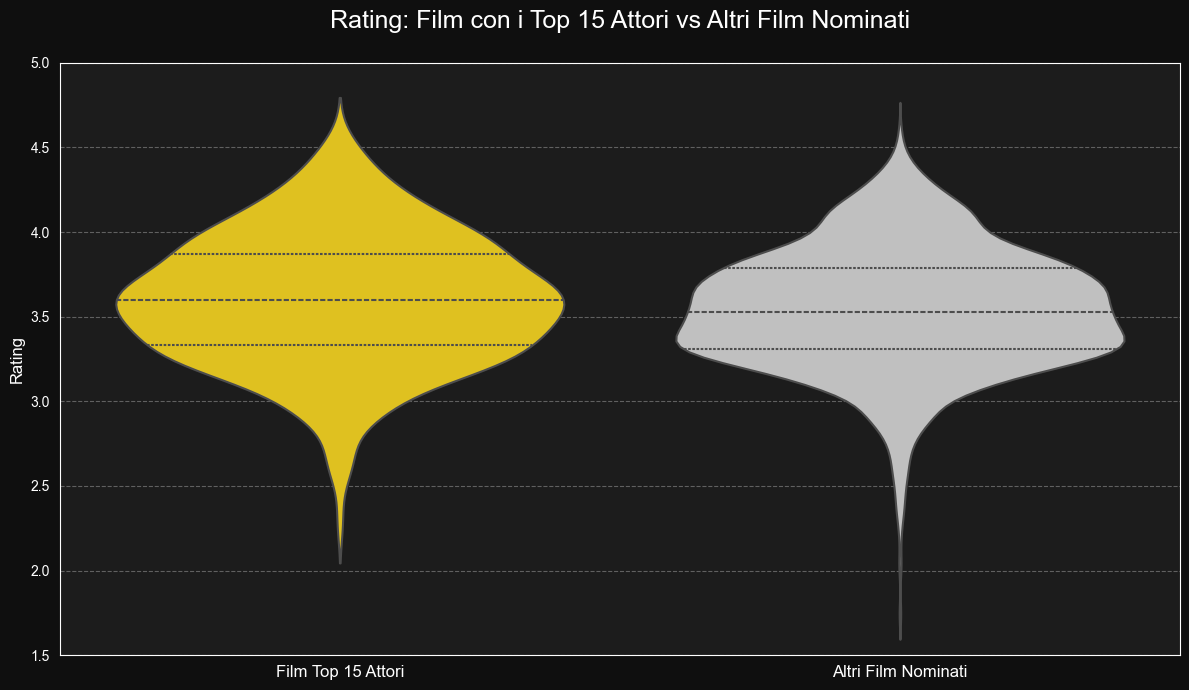

In [29]:
df_oscars_merge = df_oscars.copy()
df_oscars_merge['match_title'] = df_oscars_merge['film'].astype(str).str.lower().str.strip()
df_movies['match_title'] = df_movies['name'].astype(str).str.lower().str.strip()

oscars_won = df_oscars_merge[df_oscars_merge['winner'] == True].copy()

merged_data = pd.merge(
    oscars_won,
    df_movies[['match_title', 'id_film', 'date']],
    left_on=['match_title', 'year_film'],
    right_on=['match_title', 'date'],
    how='inner'
)
merged_data = pd.merge(merged_data, df_actors[['id_film', 'name']], on='id_film', how='inner')

film_oscar_counts = merged_data.groupby('name_y').size().reset_index(name='Oscars Film ')

personal_wins = merged_data[
    merged_data['category'].str.contains('ACTOR|ACTRESS', case=False, na=False) &
    (merged_data['name_x'] == merged_data['name_y'])
]

personal_oscar_counts = personal_wins.groupby('name_y').size().reset_index(name='Oscars Personali')

df_comparison = pd.merge(film_oscar_counts, personal_oscar_counts, on='name_y', how='left').fillna(0)
df_comparison.rename(columns={'name_y': 'name'}, inplace=True)

top_legends = df_comparison.sort_values(by=['Oscars Personali', 'Oscars Film '], ascending=False).head(15)

top_15_names = top_legends['name'].tolist()

df_plot_data = pd.merge(
    df_oscars_merge,
    df_movies[['match_title', 'date', 'id_film', 'rating']],
    left_on=['match_title', 'year_film'],
    right_on=['match_title', 'date'],
    how='inner'
)

top_actors_film_ids = df_actors[df_actors['name'].isin(top_15_names)]['id_film'].unique()

df_unique_movies = df_plot_data.drop_duplicates(subset=['id_film']).copy()

df_unique_movies['Category'] = df_unique_movies['id_film'].apply(
    lambda x: 'Film Top 15 Attori' if x in top_actors_film_ids else 'Altri Film Nominati'
)

plt.figure(figsize=(12, 7), facecolor='#0F0F0F')
ax = plt.gca()
ax.set_facecolor('#1C1C1C')

sns.violinplot(
    data=df_unique_movies,
    x='Category',
    y='rating',
    hue='Category',
    legend=False,
    order=['Film Top 15 Attori', 'Altri Film Nominati'],
    palette={'Film Top 15 Attori': '#ffd700', 'Altri Film Nominati': '#C0C0C0'},
    inner='quart',
    linewidth=1.5,
    ax=ax
)

plt.title('Rating: Film con i Top 15 Attori vs Altri Film Nominati', fontsize=18, color='white', pad=25)
plt.ylabel('Rating', fontsize=12, color='white')
plt.xlabel('', fontsize=12, color='white')

plt.ylim(1.5, 5.0)
plt.xticks(fontsize=12, color='white')
plt.yticks(color='white')
plt.grid(axis='y', linestyle='--', alpha=0.3, color='white')

plt.tight_layout()
plt.show()

Usando due **violin plot** mettiamo a confronto il rating tra i film interpretati dai 15 attori più premiati (violino giallo) con gli altri film nominati agli Oscars (violino grigio).

La loro forma simile ci comunica che di base entrambi i grafici mostrano il meglio del cinema ma con la differenza che quello giallo è più in vantaggio con un rating attorno al 4.0-4.5 contrariamente a quello grigio che tende a sgonfiarsi prima e ha valori minimi più bassi.

Possiamo quindi affermare che nell'eccellenza del cinema non è il nome dell'attore a fare la differenza.

### Analisi 5 : L' Identikit del Film da Oscar (durata e qualità)
- Un film per essere preso in considerazione deve possedere determinate caratteristiche o e tutto casuale?

In [30]:
# Variazione di "Miglior Film" nel tempo
best_picture_categories = [
    'BEST PICTURE',
    'BEST MOTION PICTURE',
    'OUTSTANDING PICTURE',
    'OUTSTANDING PRODUCTION',
    'OUTSTANDING MOTION PICTURE',
    'UNIQUE AND ARTISTIC PICTURE'
]

df_bp_winners = df_oscars[
    (df_oscars['category'].isin(best_picture_categories)) &
    (df_oscars['winner'] == True)
][['film', 'year_film', 'winner']]

df_bp_winners = df_bp_winners.rename(columns={
    'film': 'name',
    'year_film': 'date',
    'winner': 'won_best_picture'
})

df_bp_winners['date'] = df_bp_winners['date'].astype(int)
df_bp_winners['name'] = df_bp_winners['name'].astype(str).str.lower().str.strip()

df_trend['date'] = df_trend['date'].fillna(0).astype(int)
df_trend['name'] = df_movies['name'].astype(str).str.lower().str.strip()

df_final = pd.merge(df_trend, df_bp_winners, on=['name', 'date'], how='left')

df_final['won_best_picture'] = df_final['won_best_picture'].fillna(0).astype(int)

# Togliamo i cortometraggi (<52m) e film senza "rating"
df_clean = df_final[
    (df_final['minute'] >= 52) &
    (df_final['minute'] <= 240) &
    (df_final['rating'].notna())
].copy()

# Mappa per la Legenda
df_clean['Stato'] = df_clean['won_best_picture'].map({1: 'Vincitori Oscars', 0: 'Film Standard'})

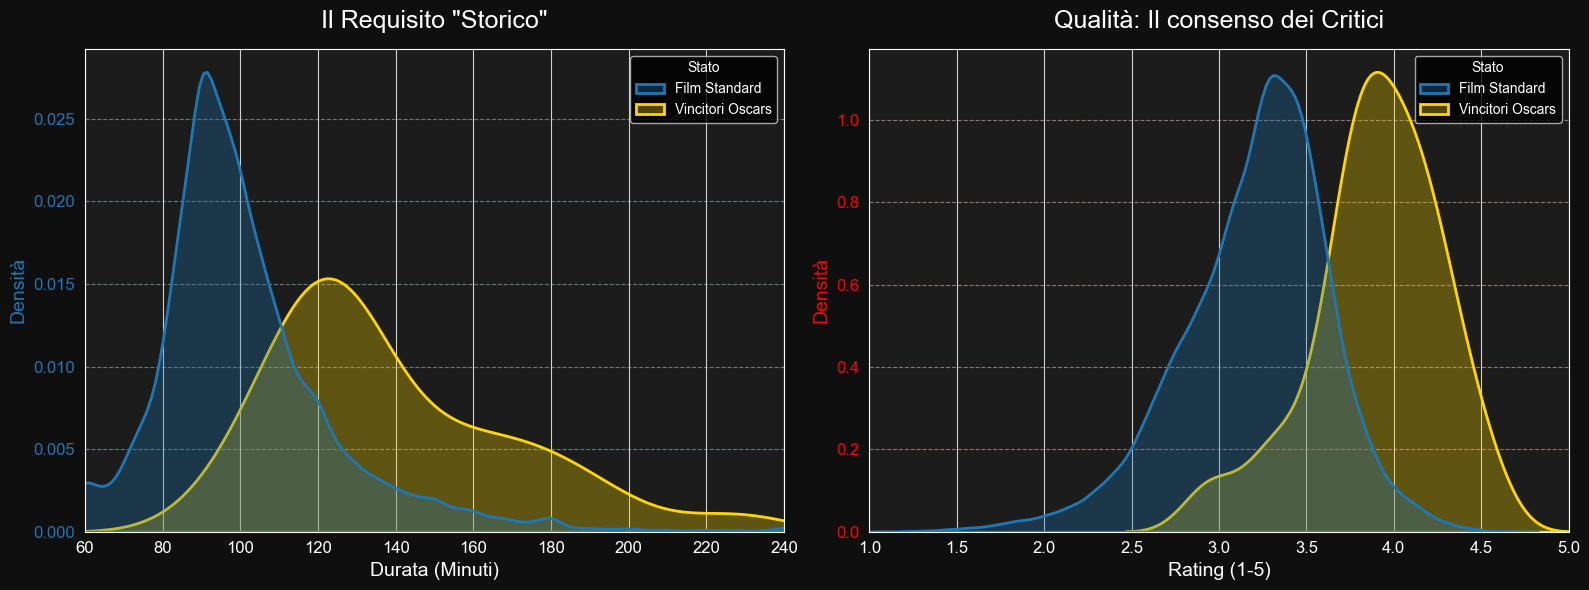

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

fig.patch.set_facecolor('#0F0F0F')

my_palette = {'Vincitori Oscars': '#FFD700', 'Film Standard': '#1f77b4'}

ax1 = axes[0]
ax1.set_facecolor('#1C1C1C')

sns.kdeplot(
    data=df_clean,
    x='minute',
    hue='Stato',
    palette=my_palette,
    fill=True,
    common_norm=False,
    alpha=0.3,
    linewidth=2,
    warn_singular=False,
    ax=ax1
)

ax1.set_title('Il Requisito "Storico"', fontsize=18, color='white', pad=15)
ax1.set_xlabel('Durata (Minuti)', fontsize=14, color='white')
ax1.set_ylabel('Densità', fontsize=14, color='#1f77b4') # Blue Label
ax1.set_xlim(60, 240)

ax1.xaxis.grid(True, color='white', linestyle='-', alpha=0.8)
ax1.yaxis.grid(True, color='lightblue', linestyle='--', alpha=0.5)
ax1.tick_params(axis='x', colors='white', labelsize=12)
ax1.tick_params(axis='y', colors='#1f77b4', labelsize=12)

ax2 = axes[1]
ax2.set_facecolor('#1C1C1C')

sns.kdeplot(
    data=df_clean,
    x='rating',
    hue='Stato',
    palette=my_palette,
    fill=True,
    common_norm=False,
    alpha=0.3,
    linewidth=2,
    warn_singular=False,
    ax=ax2
)

ax2.set_title('Qualità: Il consenso dei Critici', fontsize=18, color='white', pad=15)
ax2.set_xlabel('Rating (1-5)', fontsize=14, color='white')
ax2.set_ylabel('Densità', fontsize=14, color='red') # Red Label
ax2.set_xlim(1, 5)

ax2.xaxis.grid(True, color='white', linestyle='-', alpha=0.8)
ax2.yaxis.grid(True, color='#ffcccc', linestyle='--', alpha=0.5)
ax2.tick_params(axis='x', colors='white', labelsize=12)
ax2.tick_params(axis='y', colors='red', labelsize=12)


if ax1.get_legend():
    plt.setp(ax1.get_legend().get_texts(), color='white')
    plt.setp(ax1.get_legend().get_title(), color='white')
if ax2.get_legend():
    plt.setp(ax2.get_legend().get_texts(), color='white')
    plt.setp(ax2.get_legend().get_title(), color='white')

plt.tight_layout()
plt.show()

Come si può vedere da entrambi i grafici , "l'onda" gialla che rappresenta gli oscars è sempre più a destra in entrambi i grafici.
Nel primo caso ciò significa che generalmente la maggior parte dei film da oscar durano dai 120-140 minuti con alcuni che raggiungono i 180 e al contrario i film "standard" non superano i 100 minuti.

Nel secondo caso la critica mostra che non è soltanto una questione di lunghezza ma anche di qualità poichè il picco del rating è a 4 su 5, mentre per i film "standard" è tra i 3.0-3.5.

In conclusione possiamo con certezza affermare che durata e qualità sono caratteristiche fondamentali per la realizzazione di un film da oscar.

### Analisi 6: L'Evoluzione dei Generi
- Il genere cinematografico di un film influenza la vincita di un Oscar?

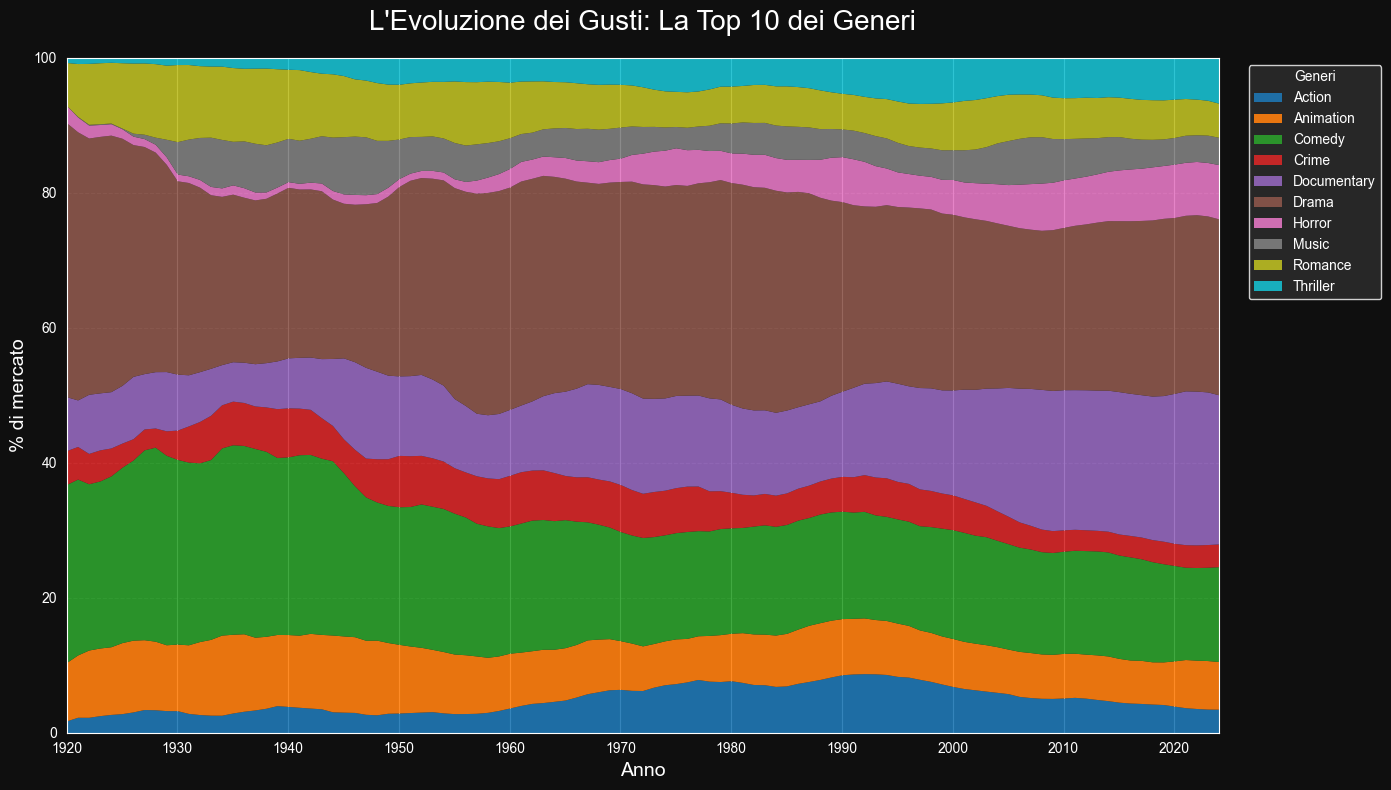

In [46]:
df_merged = pd.merge(
    df_movies[['id_film', 'date']],
    df_genres[['id_film', 'genre']],
    on='id_film',
    how='inner'
)
df_merged = df_merged[(df_merged['date'] >= 1920) & (df_merged['date'] <= 2024)]

top_genres = df_merged['genre'].value_counts().nlargest(10).index.tolist()
filtered_data = df_merged[df_merged['genre'].isin(top_genres)]

genre_counts = pd.crosstab(filtered_data['date'], filtered_data['genre'])

# Normalizzando in Percentuale
genre_share = genre_counts.div(genre_counts.sum(axis=1), axis=0) * 100

# Appiattimento raggruppando i rating ogni 5 anni
genre_share_smooth = genre_share.rolling(window=5, min_periods=1).mean()

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(14, 8), facecolor='#0F0F0F')
ax.set_facecolor('#1C1C1C')

# 'tab10' 10 colori per 10 categorie
genre_share_smooth.plot.area(
    ax=ax,
    cmap='tab10',
    alpha=0.9,
    linewidth=0
)

plt.title('L\'Evoluzione dei Gusti: La Top 10 dei Generi', fontsize=20, color='white', pad=20)
plt.xlabel('Anno', fontsize=14, color='white')
plt.ylabel('% di mercato', fontsize=14, color='white')

plt.xlim(1920, 2024)
plt.ylim(0, 100)
ax.set_xticks(np.arange(1920, 2024, 10))

plt.legend(title='Generi', bbox_to_anchor=(1.02, 1), loc='upper left',
           facecolor='#2E2E2E', edgecolor='white', labelcolor='white')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

Non è solo la qualità o la quantità dei film ad influenzare il successo degli Oscar.
È soprattutto una questione di scelta dei generi.
In particolare, il Drama (marrone) è nettamente favorito e successivamente la Commedia(verde) le qualicontinuano a sostenere da soli quasi il 60-70% della produzione globale.



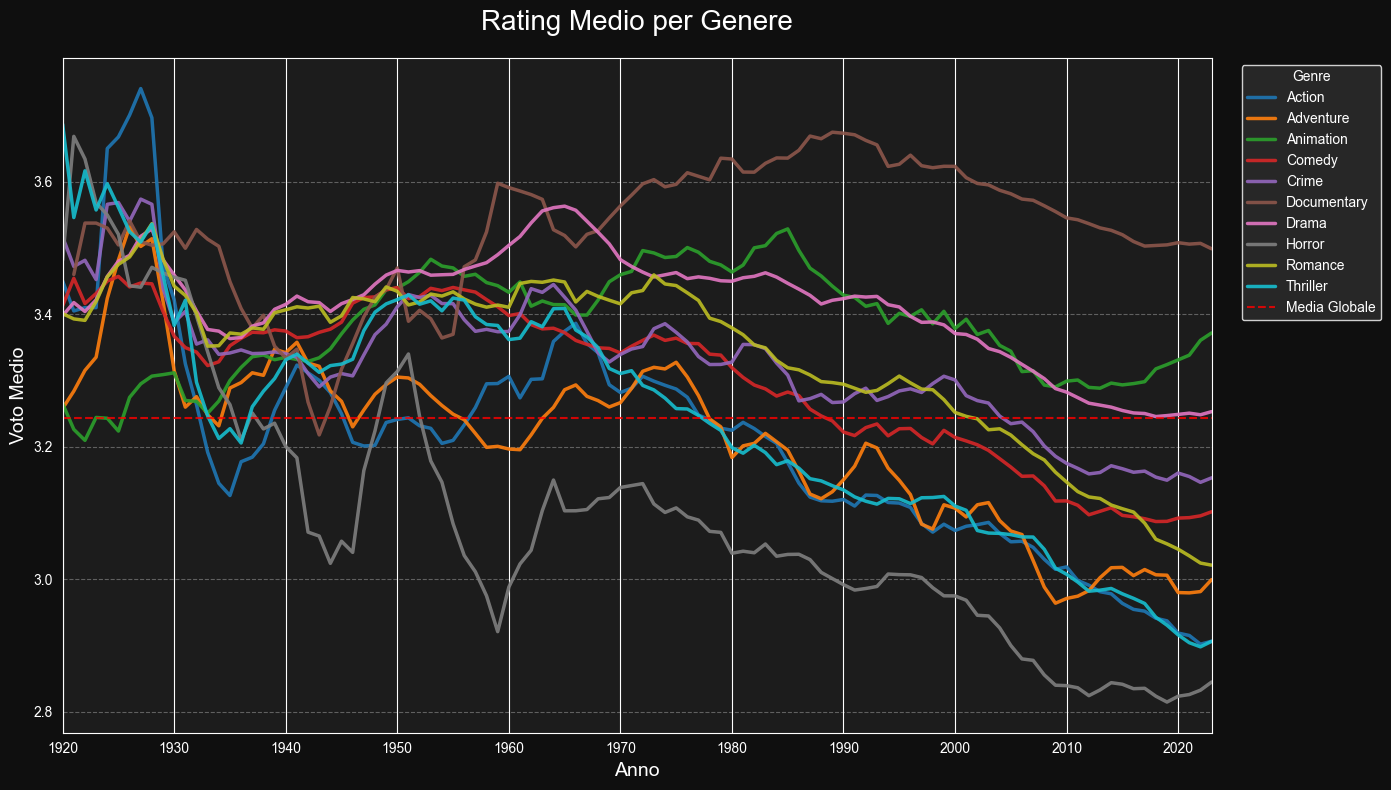

In [45]:
df_merged = pd.merge(
    df_movies[['id_film', 'date', 'rating']], 
    df_genres[['id_film', 'genre']], 
    on='id_film', 
    how='inner'
)

df_merged = df_merged[(df_merged['date'] >= 1920) & (df_merged['date'] <= 2023)]
df_merged = df_merged.dropna(subset=['rating'])

# Come prima teniamo i top 10 generi
top_genres = df_merged['genre'].value_counts().nlargest(10).index.tolist()
filtered_quality = df_merged[df_merged['genre'].isin(top_genres)]

genre_ratings = filtered_quality.groupby(['date', 'genre'])['rating'].mean().unstack()

# Appiattimento dei rating a gruppi di 5 anni
genre_ratings_smooth = genre_ratings.rolling(window=5, min_periods=1).mean()

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(14, 8), facecolor='#0F0F0F')
ax.set_facecolor('#1C1C1C')

# Stesso cmap (tab10) per avere gli stessi colori
genre_ratings_smooth.plot(
    ax=ax,
    cmap='tab10',
    linewidth=2.5,
    alpha=0.9
)

plt.title('Rating Medio per Genere', fontsize=20, color='white', pad=20)
plt.xlabel('Anno', fontsize=14, color='white')
plt.ylabel('Voto Medio', fontsize=14, color='white')

global_avg = df_movies['rating'].mean()
plt.axhline(global_avg, color='red', linestyle='--', alpha=0.8, label='Media Globale')

plt.xlim(1920, 2023)
ax.set_xticks(np.arange(1920, 2024, 10))

plt.legend(title='Genre', bbox_to_anchor=(1.02, 1), loc='upper left',
           facecolor='#2E2E2E', edgecolor='white', labelcolor='white')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

Il grafico mostra come la linea Marrone (Documentari) domina la parte alta del grafico soprattutto dagli anni '60 in poi, staccandosi nettamente tutti gli altri.
Dall'altra parte invece troviamo l'Horror (grigio). La linea grigia è costantemente la più bassa, andando ben al di sotto della media globale (spesso sotto il 3.0). Questo suggerisce che per critica e pubblico è molto difficile prendere sul serio un film dell'orrore e ciò fa pensare che un regista di film Horror deve faticare il doppio per ottenere lo stesso voto di un documentarista

In [37]:
df_oscars_merge = df_oscars.copy()
df_oscars_merge['match_title'] = df_oscars_merge['film'].astype(str).str.lower().str.strip()
df_movies['match_title'] = df_movies['name'].astype(str).str.lower().str.strip()

oscars_won = df_oscars_merge[df_oscars_merge['winner'] == True].copy()

merged_data = pd.merge(
    oscars_won,
    df_movies[['match_title', 'id_film', 'date']],
    left_on=['match_title', 'year_film'],
    right_on=['match_title', 'date'],
    how='inner'
)

df_oscar_data = pd.merge(
    merged_data,
    df_genres[['id_film', 'genre']],
    on='id_film',
    how='inner'
)

all_movies_genres = pd.merge(
    df_movies[['id_film', 'date']],
    df_genres[['id_film', 'genre']],
    on='id_film',
    how='inner'
)

all_movies_genres = all_movies_genres[(all_movies_genres['date'] >= 1920) & (all_movies_genres['date'] <= 2024)]

oscar_counts = df_oscar_data['genre'].value_counts().rename('total_oscars')

film_counts = all_movies_genres['genre'].value_counts().rename('total_films')

genre_stats = pd.concat([oscar_counts, film_counts], axis=1).fillna(0)

# efficienza= Oscar Vinti / No Film Prodotti
genre_stats['oscars_per_film'] = genre_stats['total_oscars'] / genre_stats['total_films']

top_active_genres = genre_stats['total_films'].nlargest(15).index
df_plot = genre_stats.loc[top_active_genres]

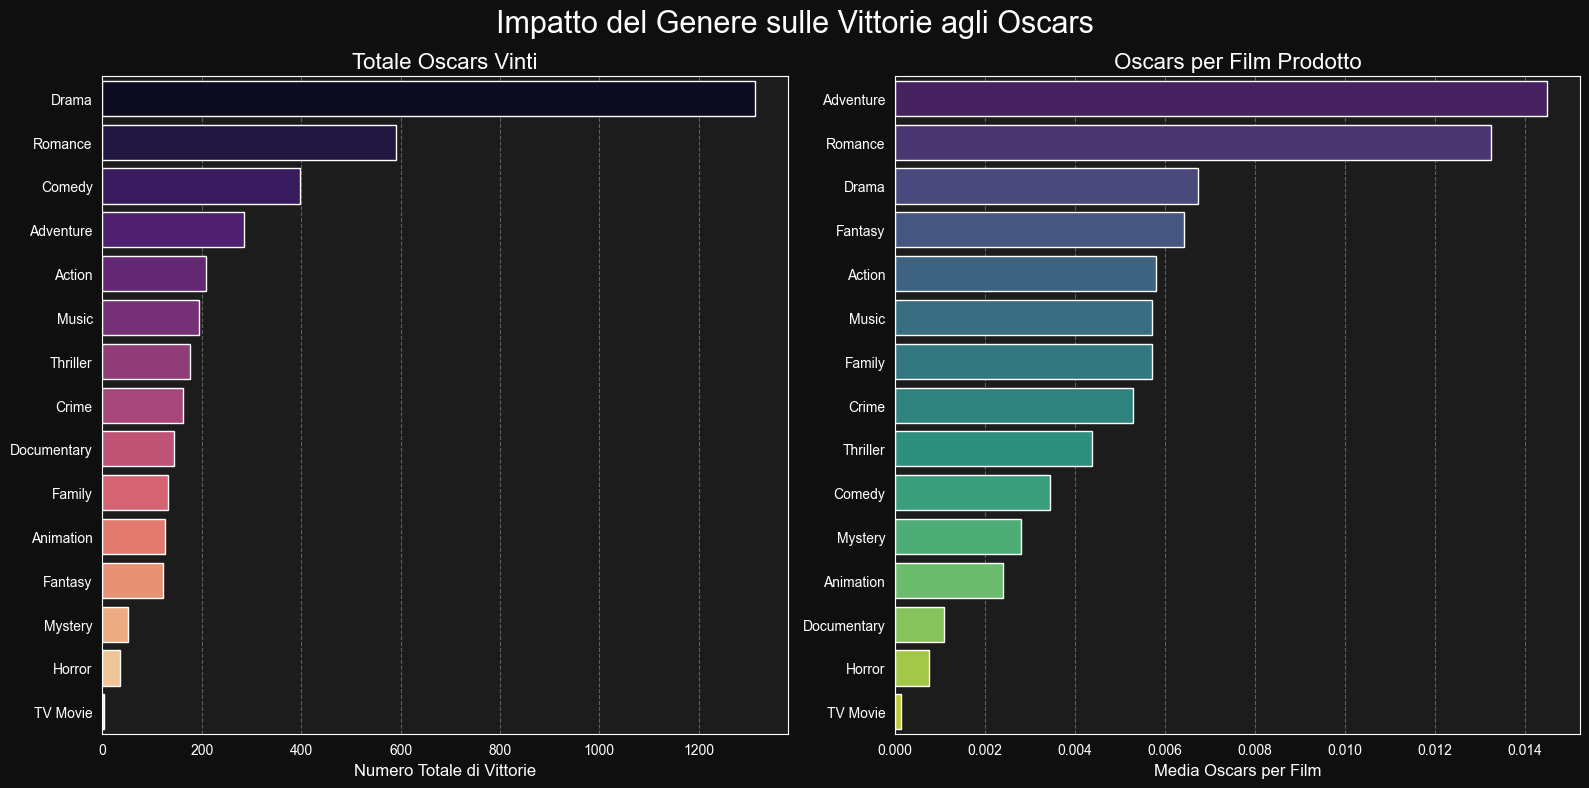

In [40]:
plt.style.use('dark_background')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), facecolor='#0F0F0F')
fig.suptitle('Impatto del Genere sulle Vittorie agli Oscars', fontsize=22, color='white')

df_sorted_total = df_plot.sort_values('total_oscars', ascending=False)
sns.barplot(
    x=df_sorted_total['total_oscars'],
    y=df_sorted_total.index,
    hue=df_sorted_total.index,
    legend=False,
    ax=ax1,
    palette='magma'
)
ax1.set_title('Totale Oscars Vinti', fontsize=16, color='white')
ax1.set_xlabel('Numero Totale di Vittorie', fontsize=12)
ax1.set_ylabel('')
ax1.set_facecolor('#1C1C1C')
ax1.grid(axis='x', linestyle='--', alpha=0.3)

df_sorted_eff = df_plot.sort_values('oscars_per_film', ascending=False)
sns.barplot(
    x=df_sorted_eff['oscars_per_film'],
    y=df_sorted_eff.index,
    hue=df_sorted_eff.index,
    legend=False,
    ax=ax2,
    palette='viridis')

ax2.set_title('Oscars per Film Prodotto', fontsize=16, color='white')
ax2.set_xlabel('Media Oscars per Film', fontsize=12)
ax2.set_ylabel('')
ax2.set_facecolor('#1C1C1C')
ax2.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

L'ipotesi che "i vincitori di Oscars siano solo film drammatici" è vera solo in parte. Nonostante nel grafico a sinistra possiamo vedere come la maggior parte delle vittorie appartengano a questo genere, nel grafico di destra notiamo come la media di Oscars vinti per ogni film non sia la più alta, ciò ci fa capire come in realtà sia la quantità delle produzioni ad influenzare il numero di statuette.

Al contrario riusciamo a verificare che, sebbene abbiano un numero di vittorie minore, i film "Di Avventura" o "Romantici" siano più apprezzati dall'Accademy e abbiano una probabilità più alta di vincere.

Guardando questi due grafici possiamo concludere con certezza che il genere influisce almeno parzialmente sulla vincita agli Oscars.

